# Fake Job Postings: EDA and Classic ML Model Comparison

This notebook compares the cleaned feature-engineered dataset (`Data/fake_jobs_cleaned.csv`) with the original Kaggle-style dataset (`Data/fake_job_postings.csv`).

Goals:
- Understand class imbalance and missingness.
- Compare text, categorical, and numeric feature patterns across real and fake postings.
- Run stratified cross-validation on several classic machine learning models.
- Save charts, tables, and model summaries into `results/` for easy project reporting.

In [1]:
# Core setup
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('Data')
RESULTS_DIR = Path('results')
FIG_DIR = RESULTS_DIR / 'figures'
TABLE_DIR = RESULTS_DIR / 'tables'
MODEL_DIR = RESULTS_DIR / 'model_outputs'
for directory in [RESULTS_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'cleaned': DATA_DIR / 'fake_jobs_cleaned.csv',
    'original': DATA_DIR / 'fake_job_postings.csv',
}
TARGET = 'fraudulent'
RANDOM_STATE = 42
N_SPLITS = 5

print('Results will be saved to:', RESULTS_DIR.resolve())

Results will be saved to: C:\Users\patri\OneDrive\Documents\Coding\Python Scripts\ML1\results


In [2]:
# Helper functions
TEXT_COLUMNS = ['title', 'company_profile', 'description', 'requirements', 'benefits']
BASE_CATEGORICAL_COLUMNS = [
    'location', 'department', 'employment_type', 'required_experience',
    'required_education', 'industry', 'function'
]
ID_COLUMNS = ['job_id']


def slugify(value):
    return re.sub(r'[^a-zA-Z0-9_]+', '_', str(value)).strip('_').lower()


def savefig(name):
    path = FIG_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    return path


def display_and_save_table(df, name, index=True):
    path = TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=index)
    display(df)
    print(f'Saved: {path}')


def load_dataset(path):
    df = pd.read_csv(path)
    if TARGET not in df.columns:
        raise ValueError(f'Missing target column: {TARGET}')
    return df


def prepare_features(df):
    X = df.drop(columns=[TARGET]).copy()
    available_text = [c for c in TEXT_COLUMNS if c in X.columns]
    for col in available_text:
        X[col] = X[col].fillna('').astype(str)
    X['text_all'] = X[available_text].agg(' '.join, axis=1) if available_text else ''

    # Keep original text columns out of the structured transformer because text_all contains them.
    drop_cols = [c for c in ID_COLUMNS + available_text if c in X.columns]
    X_model = X.drop(columns=drop_cols, errors='ignore')

    categorical_cols = [c for c in BASE_CATEGORICAL_COLUMNS if c in X_model.columns]
    numeric_cols = [c for c in X_model.columns if c not in categorical_cols + ['text_all']]

    # Some engineered columns may be read as object if they contain unusual values; keep only true numeric columns.
    numeric_cols = [c for c in numeric_cols if pd.api.types.is_numeric_dtype(X_model[c])]
    passthrough_cols = ['text_all'] + categorical_cols + numeric_cols
    X_model = X_model[passthrough_cols]
    return X_model, df[TARGET].astype(int), categorical_cols, numeric_cols


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=True):
    transformers = []
    if use_text:
        transformers.append((
            'text',
            TfidfVectorizer(
                lowercase=True,
                stop_words='english',
                max_features=6000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True,
            ),
            'text_all'
        ))
    if use_metadata and categorical_cols:
        transformers.append((
            'categorical',
            Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', make_one_hot_encoder()),
            ]),
            categorical_cols
        ))
    if use_metadata and numeric_cols:
        transformers.append((
            'numeric',
            Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', MaxAbsScaler()),
            ]),
            numeric_cols
        ))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def make_models(categorical_cols, numeric_cols):
    text_metadata = make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=True)
    text_only = make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=False)
    metadata_only = make_preprocessor(categorical_cols, numeric_cols, use_text=False, use_metadata=True)

    return {
        'Dummy majority baseline': Pipeline([
            ('features', text_metadata),
            ('model', DummyClassifier(strategy='most_frequent')),
        ]),
        'Logistic Regression balanced': Pipeline([
            ('features', text_metadata),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        'Linear SVM balanced': Pipeline([
            ('features', text_metadata),
            ('model', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'Complement Naive Bayes text only': Pipeline([
            ('features', text_only),
            ('model', ComplementNB(alpha=0.5)),
        ]),
        'Random Forest metadata only': Pipeline([
            ('features', metadata_only),
            ('model', RandomForestClassifier(
                n_estimators=250,
                class_weight='balanced_subsample',
                min_samples_leaf=2,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def positive_precision(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)


def positive_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)


def positive_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, pos_label=1, zero_division=0)

SCORING = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'precision_fake': make_scorer(positive_precision),
    'recall_fake': make_scorer(positive_recall),
    'f1_fake': make_scorer(positive_f1),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [3]:
# Load datasets
raw_datasets = {name: load_dataset(path) for name, path in DATASETS.items()}

summary_rows = []
for name, df in raw_datasets.items():
    counts = df[TARGET].value_counts().sort_index()
    summary_rows.append({
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'real_count': int(counts.get(0, 0)),
        'fake_count': int(counts.get(1, 0)),
        'fake_rate': counts.get(1, 0) / len(df),
    })

summary = pd.DataFrame(summary_rows)
display_and_save_table(summary, 'dataset_summary', index=False)

,dataset,rows,columns,real_count,fake_count,fake_rate
0,cleaned,17880,32,17014,866,0.048434
1,original,17880,18,17014,866,0.048434


Saved: results\tables\dataset_summary.csv


## Exploratory Data Analysis

The EDA below is repeated for the cleaned and original datasets. Because fake postings are the minority class, most charts separate real and fake postings rather than only showing overall averages.

### Cleaned Dataset

Shape: (17880, 32)
Columns: job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent, title_length, description_length, requirements_length, company_profile_length, benefits_length, has_salary_range, has_benefits, has_company_profile, has_department, title_word_count, description_word_count, requirements_word_count, company_profile_word_count, benefits_word_count


,count,rate
fraudulent,,
Real,17014,0.951566
Fake,866,0.048434


Saved: results\tables\cleaned_class_balance.csv


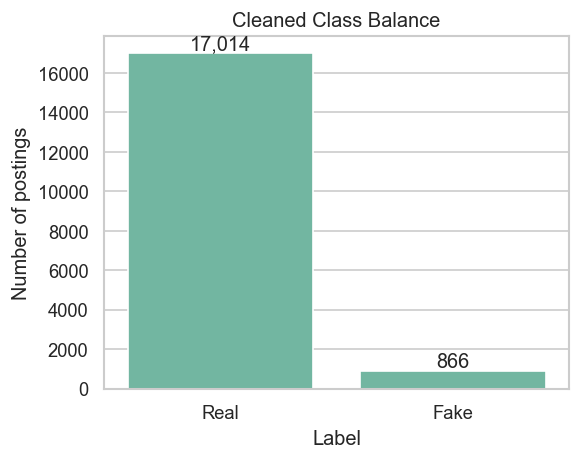

,missing_rate
salary_range,0.839597
benefits,0.403356
company_profile,0.185011
requirements,0.150783
location,0.019351
description,0.000056
job_id,0.000000
department,0.000000
title,0.000000
telecommuting,0.000000


Saved: results\tables\cleaned_missing_rates_top15.csv


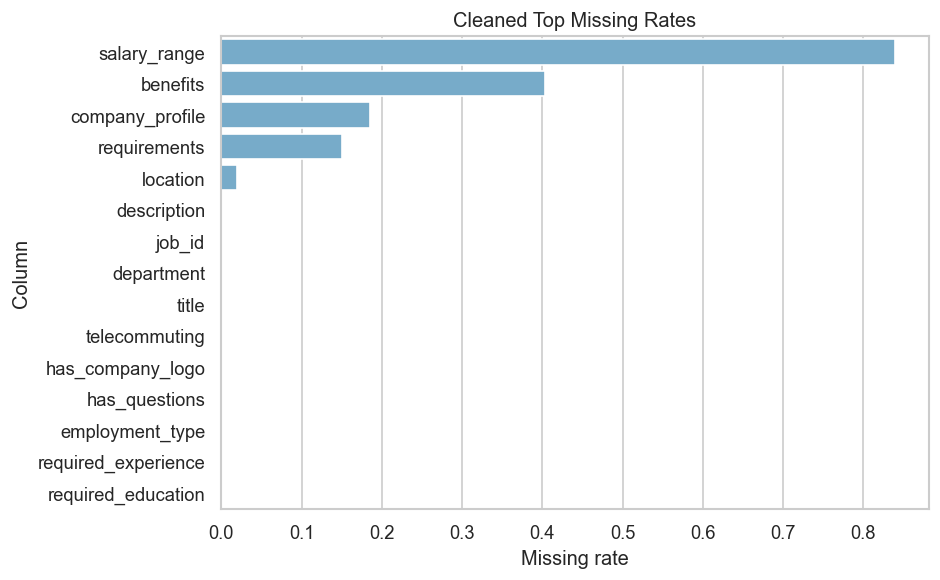

### Original Dataset

Shape: (17880, 18)
Columns: job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent


,count,rate
fraudulent,,
Real,17014,0.951566
Fake,866,0.048434


Saved: results\tables\original_class_balance.csv


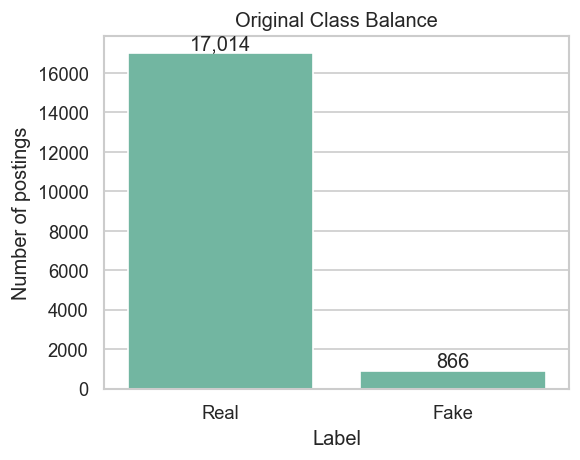

,missing_rate
salary_range,0.839597
department,0.645805
required_education,0.453300
benefits,0.403356
required_experience,0.394295
function,0.361018
industry,0.274217
employment_type,0.194128
company_profile,0.185011
requirements,0.150783


Saved: results\tables\original_missing_rates_top15.csv


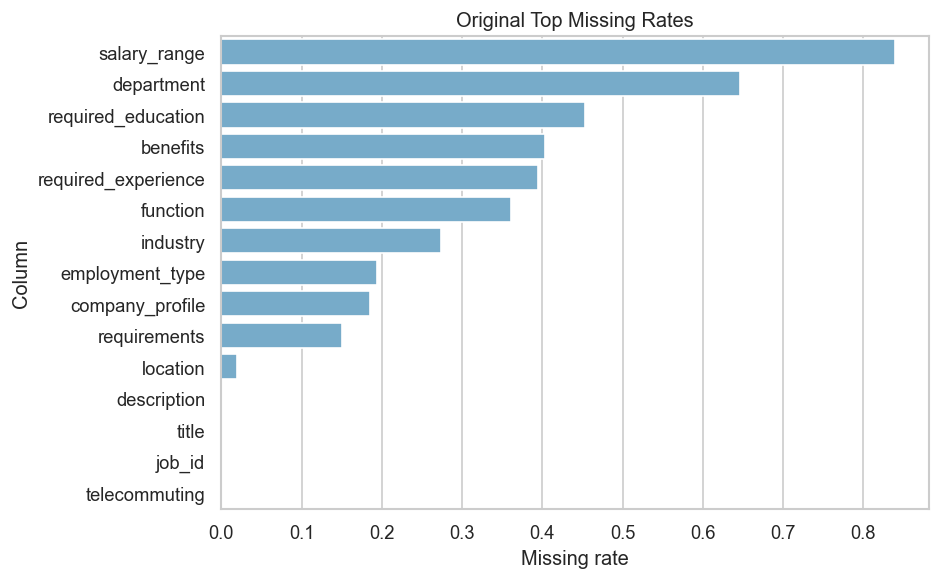

In [4]:
# EDA: class balance and missingness
for name, df in raw_datasets.items():
    display(Markdown(f'### {name.title()} Dataset'))
    print(f'Shape: {df.shape}')
    print('Columns:', ', '.join(df.columns))

    class_counts = df[TARGET].map({0: 'Real', 1: 'Fake'}).value_counts().reindex(['Real', 'Fake'])
    class_rate = (class_counts / class_counts.sum()).rename('rate')
    class_table = pd.DataFrame({'count': class_counts, 'rate': class_rate})
    display_and_save_table(class_table, f'{name}_class_balance')

    plt.figure(figsize=(5, 4))
    ax = sns.barplot(x=class_counts.index, y=class_counts.values)
    ax.set_title(f'{name.title()} Class Balance')
    ax.set_ylabel('Number of postings')
    ax.set_xlabel('Label')
    for i, val in enumerate(class_counts.values):
        ax.text(i, val, f'{val:,}', ha='center', va='bottom')
    savefig(f'{name}_class_balance')
    plt.show()

    missing = df.isna().mean().sort_values(ascending=False).head(15).rename('missing_rate').to_frame()
    display_and_save_table(missing, f'{name}_missing_rates_top15')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=missing.reset_index(), y='index', x='missing_rate', color='#6aaed6')
    plt.title(f'{name.title()} Top Missing Rates')
    plt.xlabel('Missing rate')
    plt.ylabel('Column')
    savefig(f'{name}_missing_rates_top15')
    plt.show()

### Text Length Patterns: Cleaned

mean  median    max
fraudulent field                                 
Fake       benefits          212.2    36.0   2500
           company_profile   230.9     0.0   1422
           description      1154.8   844.5   8578
           requirements      446.0   249.0   4077
           title              30.7    28.0    142
Real       benefits          208.7    47.0   4429
           company_profile   640.8   588.0   6178
           description      1221.2  1027.0  14907
           requirements      597.5   476.5  10864
           title              28.4    25.0    110

Saved: results\tables\cleaned_text_length_summary.csv


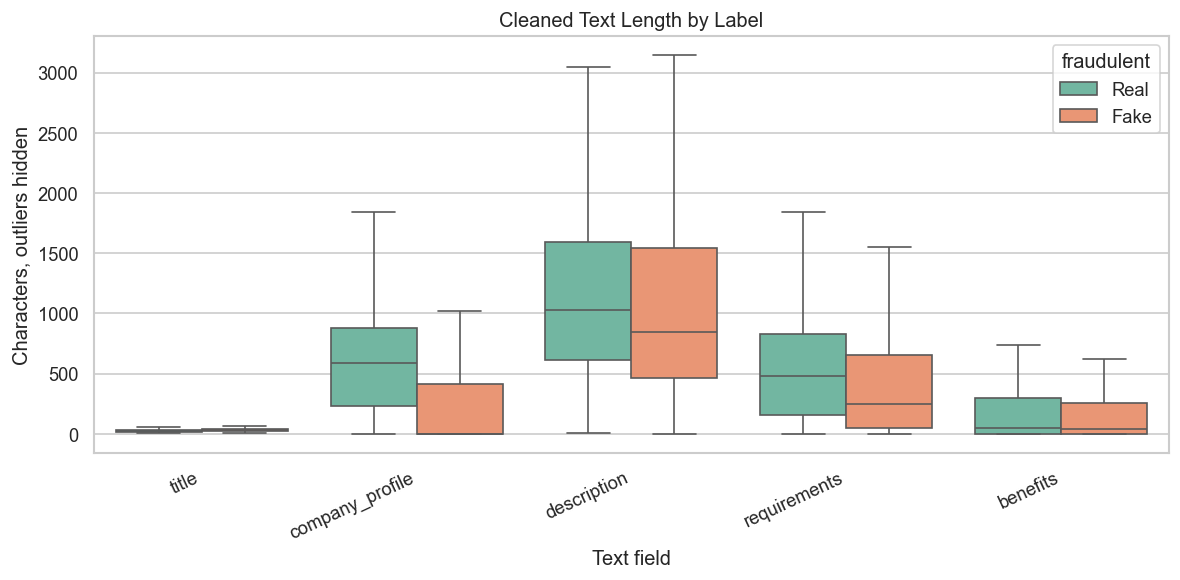

### Text Length Patterns: Original

mean  median    max
fraudulent field                                 
Fake       benefits          212.2    36.0   2500
           company_profile   230.9     0.0   1422
           description      1154.8   844.5   8578
           requirements      446.0   249.0   4077
           title              30.7    28.0    142
Real       benefits          208.7    47.0   4429
           company_profile   640.8   588.0   6178
           description      1221.2  1027.0  14907
           requirements      597.5   476.5  10864
           title              28.4    25.0    110

Saved: results\tables\original_text_length_summary.csv


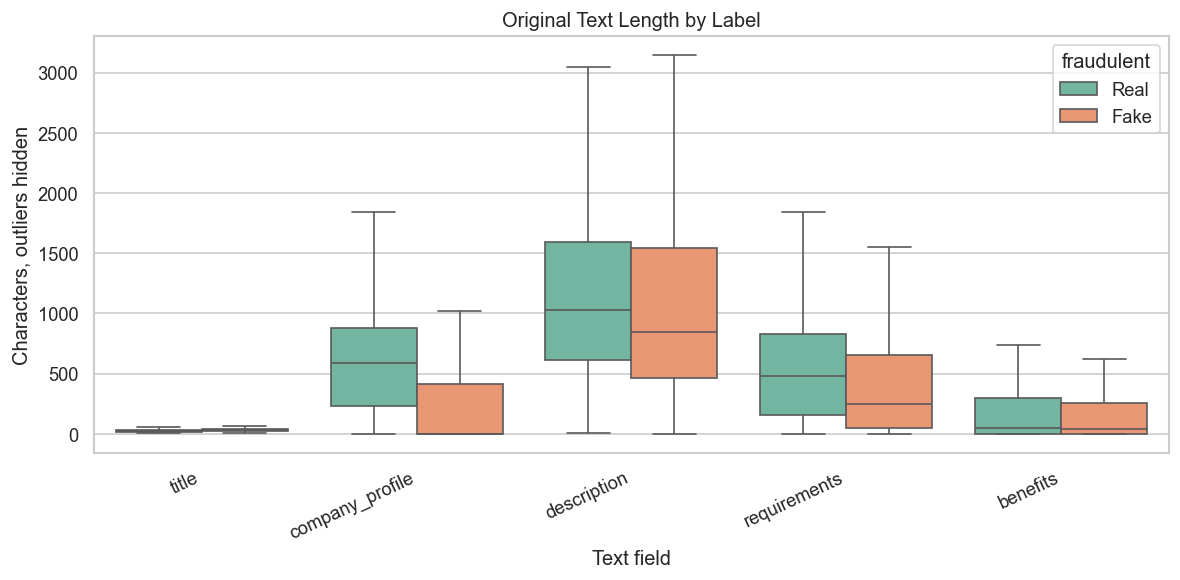

In [5]:
# EDA: text length patterns
for name, df in raw_datasets.items():
    display(Markdown(f'### Text Length Patterns: {name.title()}'))
    text_cols = [c for c in TEXT_COLUMNS if c in df.columns]
    length_frame = pd.DataFrame({
        col: df[col].fillna('').astype(str).str.len()
        for col in text_cols
    })
    length_frame[TARGET] = df[TARGET].map({0: 'Real', 1: 'Fake'})

    melted = length_frame.melt(id_vars=TARGET, var_name='field', value_name='characters')
    length_summary = melted.groupby([TARGET, 'field'])['characters'].agg(['mean', 'median', 'max']).round(1)
    display_and_save_table(length_summary, f'{name}_text_length_summary')

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted, x='field', y='characters', hue=TARGET, showfliers=False)
    plt.title(f'{name.title()} Text Length by Label')
    plt.xlabel('Text field')
    plt.ylabel('Characters, outliers hidden')
    plt.xticks(rotation=25, ha='right')
    savefig(f'{name}_text_length_by_label')
    plt.show()

### Categorical Fake Rates: Cleaned

,column,value,count,fake_rate
0,location,"US, CA, San Mateo",46,0.478261
1,location,"AU, NSW, Sydney",82,0.378049
2,location,"US, TX, Houston",269,0.342007
3,location,"US, CA, San Jose",48,0.291667
4,location,"US, CA,",34,0.264706
5,location,"US, CA, Los Angeles",185,0.124324
6,location,"US, NY,",34,0.117647
7,location,"US, WA, Seattle",57,0.105263
8,department,Administrative,30,0.466667
9,department,Customer Service,73,0.191781


Saved: results\tables\cleaned_top_categorical_fake_rates.csv


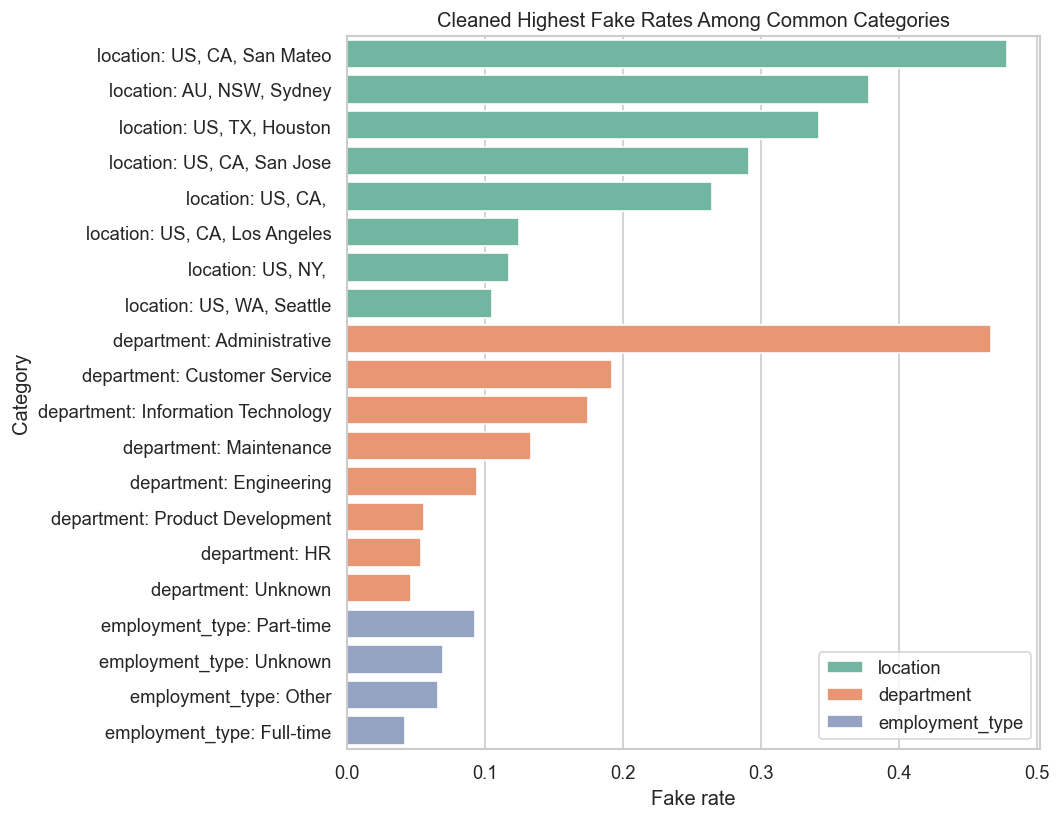

### Categorical Fake Rates: Original

,column,value,count,fake_rate
0,location,"US, CA, San Mateo",46,0.478261
1,location,"AU, NSW, Sydney",82,0.378049
2,location,"US, TX, Houston",269,0.342007
3,location,"US, CA, San Jose",48,0.291667
4,location,"US, CA,",34,0.264706
5,location,"US, CA, Los Angeles",185,0.124324
6,location,"US, NY,",34,0.117647
7,location,"US, WA, Seattle",57,0.105263
8,department,Administrative,30,0.466667
9,department,Customer Service,73,0.191781


Saved: results\tables\original_top_categorical_fake_rates.csv


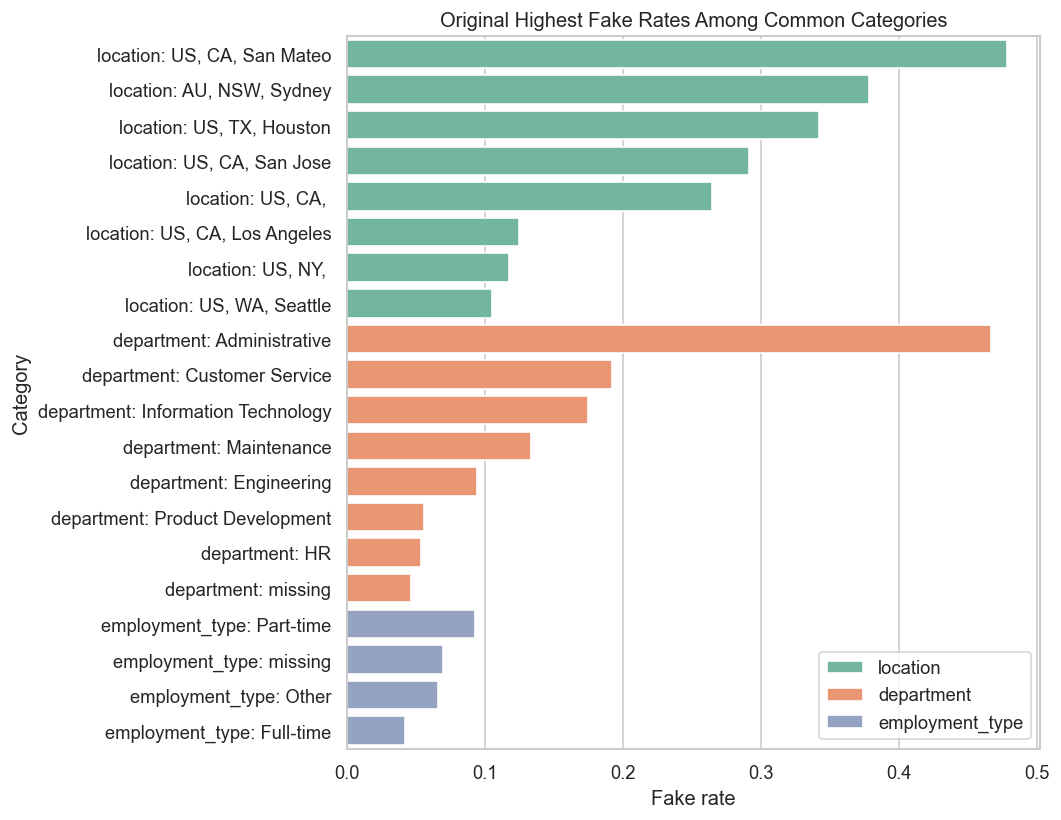

In [6]:
# EDA: categorical fields with the highest fake rates
for name, df in raw_datasets.items():
    display(Markdown(f'### Categorical Fake Rates: {name.title()}'))
    cat_cols = [c for c in BASE_CATEGORICAL_COLUMNS if c in df.columns]
    frames = []
    for col in cat_cols:
        temp = df[[col, TARGET]].copy()
        temp[col] = temp[col].fillna('missing').astype(str)
        grouped = temp.groupby(col)[TARGET].agg(['count', 'mean']).rename(columns={'mean': 'fake_rate'})
        grouped = grouped[grouped['count'] >= 30].sort_values('fake_rate', ascending=False).head(8)
        grouped.insert(0, 'column', col)
        grouped.insert(1, 'value', grouped.index)
        frames.append(grouped.reset_index(drop=True))
    cat_rates = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display_and_save_table(cat_rates, f'{name}_top_categorical_fake_rates', index=False)

    if not cat_rates.empty:
        plot_data = cat_rates.head(20).copy()
        plot_data['label'] = plot_data['column'] + ': ' + plot_data['value'].str.slice(0, 35)
        plt.figure(figsize=(9, 7))
        sns.barplot(data=plot_data, y='label', x='fake_rate', hue='column', dodge=False)
        plt.title(f'{name.title()} Highest Fake Rates Among Common Categories')
        plt.xlabel('Fake rate')
        plt.ylabel('Category')
        plt.legend(loc='lower right')
        savefig(f'{name}_top_categorical_fake_rates')
        plt.show()

## Cross-Validated Model Comparison

The models below are intentionally classic and explainable enough for an introductory machine learning project:

- Dummy majority baseline: shows why accuracy is not enough.
- Logistic Regression with class weights: strong baseline for sparse text features.
- Linear SVM with class weights: another strong linear text classifier.
- Complement Naive Bayes: simple text-only baseline often used for imbalanced text classification.
- Random Forest on metadata only: tests how far non-text structured fields can go.

The main ranking metric is `average_precision` because it focuses on finding the rare fake class across decision thresholds.

In [7]:
# Run cross-validation comparisons
all_results = []
fitted_feature_info = []

for dataset_name, df in raw_datasets.items():
    display(Markdown(f'### Cross-validation: {dataset_name.title()}'))
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    models = make_models(categorical_cols, numeric_cols)
    fitted_feature_info.append({
        'dataset': dataset_name,
        'categorical_features': ', '.join(categorical_cols),
        'numeric_features': ', '.join(numeric_cols),
        'positive_class_rate': y.mean(),
    })
    print('Categorical features:', categorical_cols)
    print('Numeric features:', numeric_cols)

    for model_name, estimator in models.items():
        print(f'Running {dataset_name} | {model_name}...')
        scores = cross_validate(
            estimator,
            X,
            y,
            cv=cv,
            scoring=SCORING,
            n_jobs=-1,
            return_train_score=False,
            error_score='raise',
        )
        row = {'dataset': dataset_name, 'model': model_name}
        for metric_name in SCORING:
            values = scores[f'test_{metric_name}']
            row[f'{metric_name}_mean'] = values.mean()
            row[f'{metric_name}_std'] = values.std()
        all_results.append(row)

cv_results = pd.DataFrame(all_results)
metric_cols = [c for c in cv_results.columns if c.endswith('_mean')]
cv_results_sorted = cv_results.sort_values(['dataset', 'average_precision_mean'], ascending=[True, False])
display_and_save_table(cv_results_sorted.round(4), 'cv_model_comparison', index=False)

feature_info = pd.DataFrame(fitted_feature_info)
display_and_save_table(feature_info, 'model_feature_columns', index=False)

### Cross-validation: Cleaned

Categorical features: ['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
Numeric features: ['telecommuting', 'has_company_logo', 'has_questions', 'title_length', 'description_length', 'requirements_length', 'company_profile_length', 'benefits_length', 'has_salary_range', 'has_benefits', 'has_company_profile', 'has_department', 'title_word_count', 'description_word_count', 'requirements_word_count', 'company_profile_word_count', 'benefits_word_count']
Running cleaned | Dummy majority baseline...


Running cleaned | Logistic Regression balanced...


Running cleaned | Linear SVM balanced...


Running cleaned | Complement Naive Bayes text only...


...

Running original | Random Forest metadata only...


,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_fake_mean,precision_fake_std,recall_fake_mean,recall_fake_std,f1_fake_mean,f1_fake_std
2,cleaned,Linear SVM balanced,0.9858,0.0007,0.9164,0.0093,0.9890,0.0019,0.9140,0.0147,0.8636,0.0095,0.8395,0.0189,0.8512,0.0086
1,cleaned,Logistic Regression balanced,0.9706,0.0031,0.9325,0.0080,0.9884,0.0018,0.8810,0.0182,0.6430,0.0271,0.8903,0.0148,0.7464,0.0211
3,cleaned,Complement Naive Bayes text only,0.8261,0.0111,0.8714,0.0090,0.9539,0.0077,0.7387,0.0398,0.2084,0.0103,0.9215,0.0177,0.3398,0.0138
4,cleaned,Random Forest metadata only,0.9145,0.0046,0.8899,0.0096,0.9651,0.0034,0.7145,0.0245,0.3469,0.0142,0.8626,0.0179,0.4947,0.0160
0,cleaned,Dummy majority baseline,0.9516,0.0001,0.5000,0.0000,0.5000,0.0000,0.0484,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,original,Linear SVM balanced,0.9858,0.0004,0.9147,0.0073,0.9880,0.0026,0.9128,0.0131,0.8665,0.0146,0.8361,0.0155,0.8508,0.0045
6,original,Logistic Regression balanced,0.9730,0.0030,0.9338,0.0057,0.9876,0.0025,0.8850,0.0175,0.6666,0.0309,0.8903,0.0107,0.7620,0.0212
8,original,Complement Naive Bayes text only,0.8261,0.0111,0.8714,0.0090,0.9539,0.0077,0.7387,0.0398,0.2084,0.0103,0.9215,0.0177,0.3398,0.0138
9,original,Random Forest metadata only,0.9199,0.0021,0.8845,0.0158,0.9569,0.0045,0.7143,0.0352,0.3604,0.0091,0.8453,0.0321,0.5053,0.0140
5,original,Dummy majority baseline,0.9516,0.0001,0.5000,0.0000,0.5000,0.0000,0.0484,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Saved: results\tables\cv_model_comparison.csv


,dataset,categorical_features,numeric_features,positive_class_rate
0,cleaned,"location, department, employment_type, require...","telecommuting, has_company_logo, has_questions...",0.048434
1,original,"location, department, employment_type, require...","telecommuting, has_company_logo, has_questions",0.048434


Saved: results\tables\model_feature_columns.csv


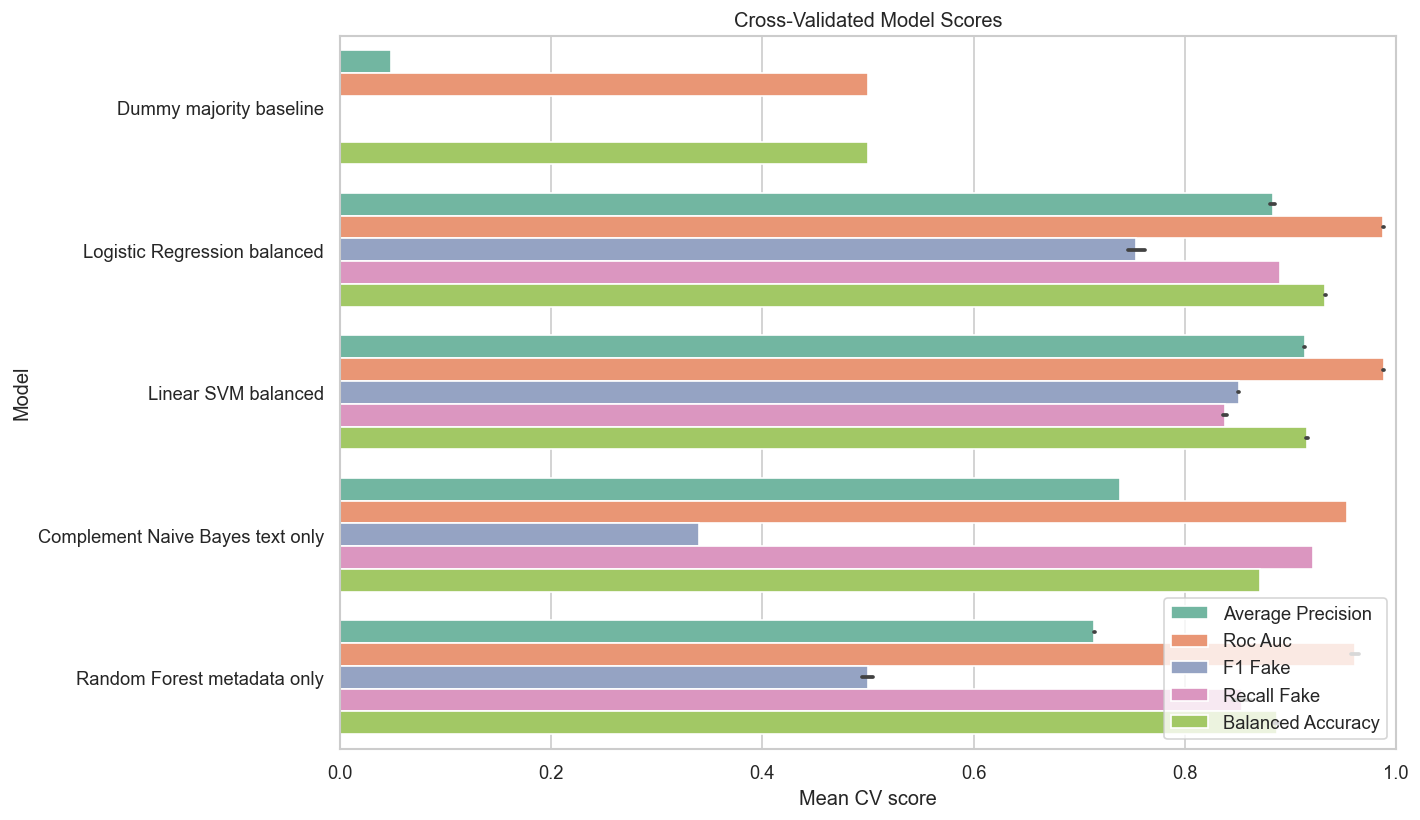

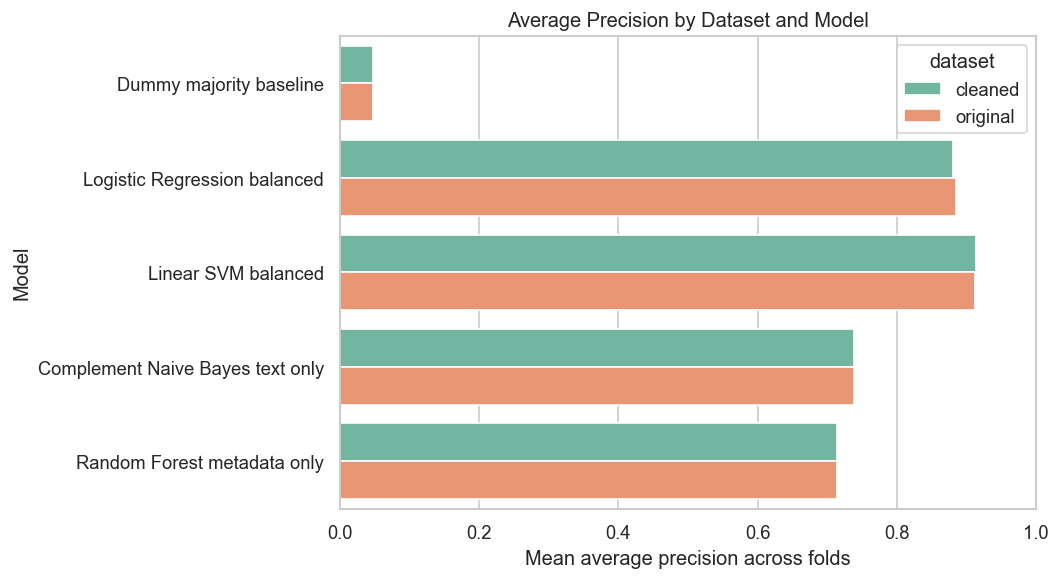

In [8]:
# Plot CV results
plot_metrics = ['average_precision_mean', 'roc_auc_mean', 'f1_fake_mean', 'recall_fake_mean', 'balanced_accuracy_mean']
plot_data = cv_results.melt(
    id_vars=['dataset', 'model'],
    value_vars=plot_metrics,
    var_name='metric',
    value_name='score'
)
plot_data['metric'] = plot_data['metric'].str.replace('_mean', '', regex=False).str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_data, x='score', y='model', hue='metric')
plt.title('Cross-Validated Model Scores')
plt.xlabel('Mean CV score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.legend(loc='lower right')
savefig('cv_model_scores_all_metrics')
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=cv_results, x='average_precision_mean', y='model', hue='dataset')
plt.title('Average Precision by Dataset and Model')
plt.xlabel('Mean average precision across folds')
plt.ylabel('Model')
plt.xlim(0, 1)
savefig('average_precision_by_dataset_model')
plt.show()

### Best Model by Average Precision: Cleaned

Linear SVM balanced


,dataset,model,precision,recall,f1-score,support
Real,cleaned,Linear SVM balanced,0.9918,0.9932,0.9925,17014.0000
Fake,cleaned,Linear SVM balanced,0.8634,0.8395,0.8513,866.0000
accuracy,cleaned,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
macro avg,cleaned,Linear SVM balanced,0.9276,0.9164,0.9219,17880.0000
weighted avg,cleaned,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


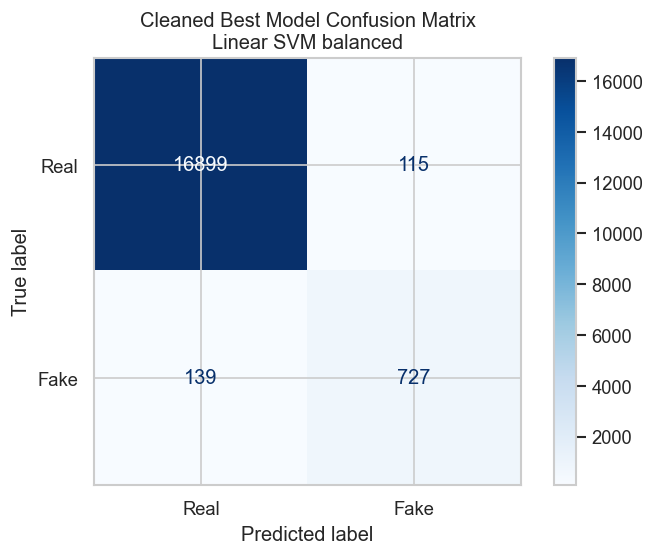

### Best Model by Average Precision: Original

Linear SVM balanced


,dataset,model,precision,recall,f1-score,support
Real,original,Linear SVM balanced,0.9917,0.9934,0.9925,17014.0000
Fake,original,Linear SVM balanced,0.8660,0.8360,0.8508,866.0000
accuracy,original,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
macro avg,original,Linear SVM balanced,0.9288,0.9147,0.9217,17880.0000
weighted avg,original,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


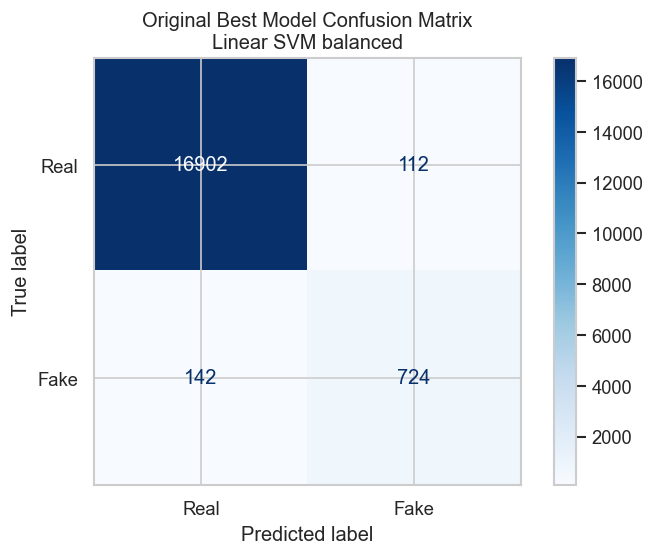

,class,dataset,model,precision,recall,f1-score,support
0,Real,cleaned,Linear SVM balanced,0.9918,0.9932,0.9925,17014.0000
1,Fake,cleaned,Linear SVM balanced,0.8634,0.8395,0.8513,866.0000
2,accuracy,cleaned,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
3,macro avg,cleaned,Linear SVM balanced,0.9276,0.9164,0.9219,17880.0000
4,weighted avg,cleaned,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000
5,Real,original,Linear SVM balanced,0.9917,0.9934,0.9925,17014.0000
6,Fake,original,Linear SVM balanced,0.8660,0.8360,0.8508,866.0000
7,accuracy,original,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
8,macro avg,original,Linear SVM balanced,0.9288,0.9147,0.9217,17880.0000
9,weighted avg,original,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


Saved: results\tables\best_model_classification_reports.csv


In [9]:
# Confusion matrices and classification reports for the best model per dataset
best_rows = cv_results.sort_values('average_precision_mean', ascending=False).groupby('dataset').head(1)
reports = []

for _, best in best_rows.iterrows():
    dataset_name = best['dataset']
    model_name = best['model']
    df = raw_datasets[dataset_name]
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    estimator = make_models(categorical_cols, numeric_cols)[model_name]

    display(Markdown(f'### Best Model by Average Precision: {dataset_name.title()}'))
    print(model_name)

    y_pred = cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method='predict')
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    report_dict = classification_report(y, y_pred, labels=[0, 1], target_names=['Real', 'Fake'], output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).T
    report_df.insert(0, 'dataset', dataset_name)
    report_df.insert(1, 'model', model_name)
    reports.append(report_df.reset_index(names='class'))

    display(report_df.round(4))
    report_df.to_csv(MODEL_DIR / f'{dataset_name}_best_model_classification_report.csv')

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{dataset_name.title()} Best Model Confusion Matrix\n{model_name}')
    savefig(f'{dataset_name}_best_model_confusion_matrix')
    plt.show()

classification_reports = pd.concat(reports, ignore_index=True)
display_and_save_table(classification_reports.round(4), 'best_model_classification_reports', index=False)

In [10]:
# Simple project-direction summary generated from results
top_by_dataset = cv_results.sort_values('average_precision_mean', ascending=False).groupby('dataset').head(1)
comparison = top_by_dataset[['dataset', 'model', 'average_precision_mean', 'roc_auc_mean', 'f1_fake_mean', 'recall_fake_mean', 'precision_fake_mean']].round(4)
display_and_save_table(comparison, 'top_model_by_dataset', index=False)

cleaned_top = comparison[comparison['dataset'] == 'cleaned'].iloc[0]
original_top = comparison[comparison['dataset'] == 'original'].iloc[0]

print('Suggested path forward:')
print(f"1. Use average precision as the main comparison metric because the fake class is only about {summary.loc[0, 'fake_rate']:.1%} of the data.")
print(f"2. Treat {cleaned_top['model']} on the cleaned dataset as the current leading baseline if interpretability and performance are both acceptable.")
print(f"3. Compare cleaned vs original results directly: cleaned AP={cleaned_top['average_precision_mean']}, original AP={original_top['average_precision_mean']}.")
print('4. For the class project, a strong next step is error analysis: inspect false positives and false negatives, then explain which words/metadata patterns drive the model.')
print('5. Avoid presenting accuracy as the headline metric; the dummy baseline can look high simply because most postings are real.')

,dataset,model,average_precision_mean,roc_auc_mean,f1_fake_mean,recall_fake_mean,precision_fake_mean
2,cleaned,Linear SVM balanced,0.9140,0.989,0.8512,0.8395,0.8636
7,original,Linear SVM balanced,0.9128,0.988,0.8508,0.8361,0.8665


Saved: results\tables\top_model_by_dataset.csv
Suggested path forward:
1. Use average precision as the main comparison metric because the fake class is only about 4.8% of the data.
2. Treat Linear SVM balanced on the cleaned dataset as the current leading baseline if interpretability and performance are both acceptable.
3. Compare cleaned vs original results directly: cleaned AP=0.914, original AP=0.9128.
4. For the class project, a strong next step is error analysis: inspect false positives and false negatives, then explain which words/metadata patterns drive the model.
5. Avoid presenting accuracy as the headline metric; the dummy baseline can look high simply because most postings are real.


## Project Framing: Beyond Accuracy

**Core research question:** How does class imbalance affect model evaluation and model selection when detecting fraudulent job postings?

Because fake postings are only about 4.84% of the dataset, a model can achieve high accuracy while missing most fake jobs. This project therefore treats accuracy as a secondary metric and focuses on minority-class performance.

**Research questions:**

1. How imbalanced is the dataset, and why does that matter?
2. Is accuracy misleading for fake job detection?
3. Which classic machine learning model performs best on the minority fake class?
4. Does the cleaned and feature-engineered dataset improve model performance compared with the original dataset?
5. Which evaluation metric gives the most useful view of model performance?
6. What tradeoff exists between catching fake jobs and falsely flagging real jobs?
7. Do class-weighted models perform better than unweighted models on minority-class metrics?
8. Which words or metadata features appear most predictive of fraudulent postings?
9. What kinds of postings are most likely to become false positives or false negatives?

**Hypotheses:**

- H1: Accuracy will overestimate model usefulness because of severe class imbalance.
- H2: Class-weighted linear models will outperform simple baselines on minority-class metrics.
- H3: Text-based models will outperform metadata-only models because fraudulent language patterns are embedded in job descriptions, requirements, and company profiles.
- H4: The cleaned dataset will improve performance slightly, but not dramatically, because TF-IDF text features already capture much of the useful signal.

## Weighted vs Unweighted Linear Models

Class weighting is one of the simplest ways to address class imbalance in classic machine learning. The next experiment compares unweighted and class-weighted versions of Logistic Regression and Linear SVM. If the imbalance hypothesis is correct, class-weighted models should improve recall and F1 for the fake class, even if accuracy changes only slightly.

Running cleaned | Logistic Regression unweighted...


Running cleaned | Logistic Regression balanced...


Running cleaned | Linear SVM unweighted...


Running cleaned | Linear SVM balanced...


Running original | Logistic Regression unweighted...


Running original | Logistic Regression balanced...


Running original | Linear SVM unweighted...


Running original | Linear SVM balanced...


,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_fake_mean,precision_fake_std,recall_fake_mean,recall_fake_std,f1_fake_mean,f1_fake_std
2,cleaned,Linear SVM unweighted,0.9871,0.0008,0.8951,0.0115,0.9887,0.0020,0.9181,0.0108,0.9301,0.0130,0.7933,0.0236,0.8559,0.0103
3,cleaned,Linear SVM balanced,0.9858,0.0007,0.9164,0.0093,0.9890,0.0019,0.9140,0.0147,0.8636,0.0095,0.8395,0.0189,0.8512,0.0086
1,cleaned,Logistic Regression balanced,0.9706,0.0031,0.9325,0.0080,0.9884,0.0018,0.8810,0.0182,0.6430,0.0271,0.8903,0.0148,0.7464,0.0211
0,cleaned,Logistic Regression unweighted,0.9799,0.0014,0.8157,0.0165,0.9854,0.0025,0.8679,0.0178,0.9292,0.0317,0.6340,0.0337,0.7527,0.0207
6,original,Linear SVM unweighted,0.9872,0.0013,0.8941,0.0152,0.9877,0.0028,0.9168,0.0099,0.9361,0.0109,0.7910,0.0307,0.8570,0.0164
7,original,Linear SVM balanced,0.9858,0.0004,0.9147,0.0073,0.9880,0.0026,0.9128,0.0131,0.8665,0.0146,0.8361,0.0155,0.8508,0.0045
5,original,Logistic Regression balanced,0.9730,0.0030,0.9338,0.0057,0.9876,0.0025,0.8850,0.0175,0.6666,0.0309,0.8903,0.0107,0.7620,0.0212
4,original,Logistic Regression unweighted,0.9797,0.0025,0.8124,0.0229,0.9842,0.0033,0.8680,0.0169,0.9316,0.0262,0.6271,0.0458,0.7487,0.0354


Saved: results\tables\weighted_vs_unweighted_linear_models.csv


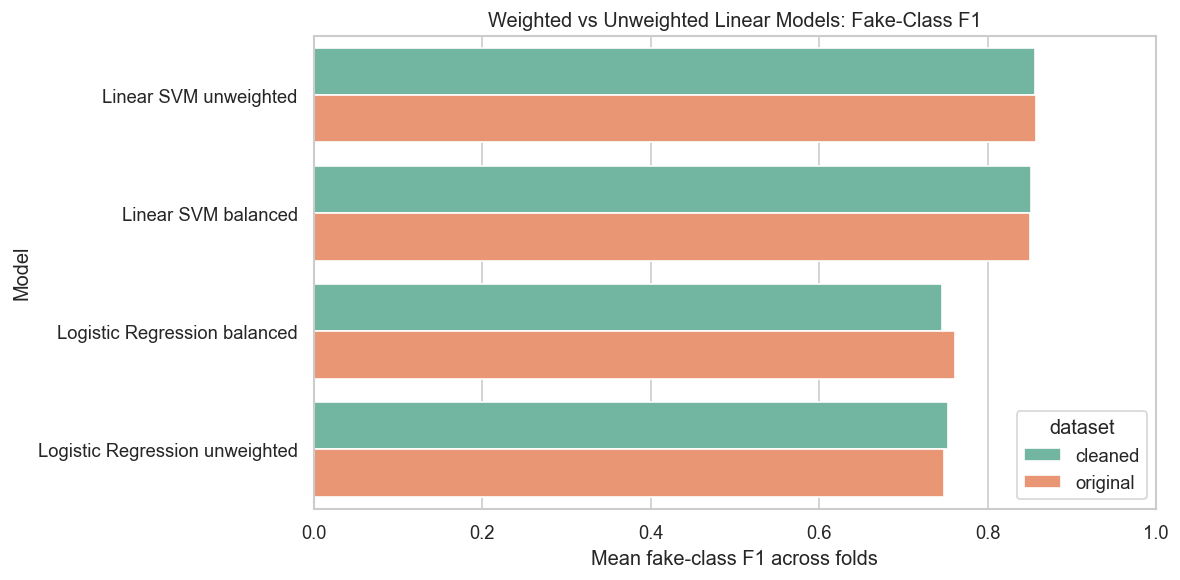

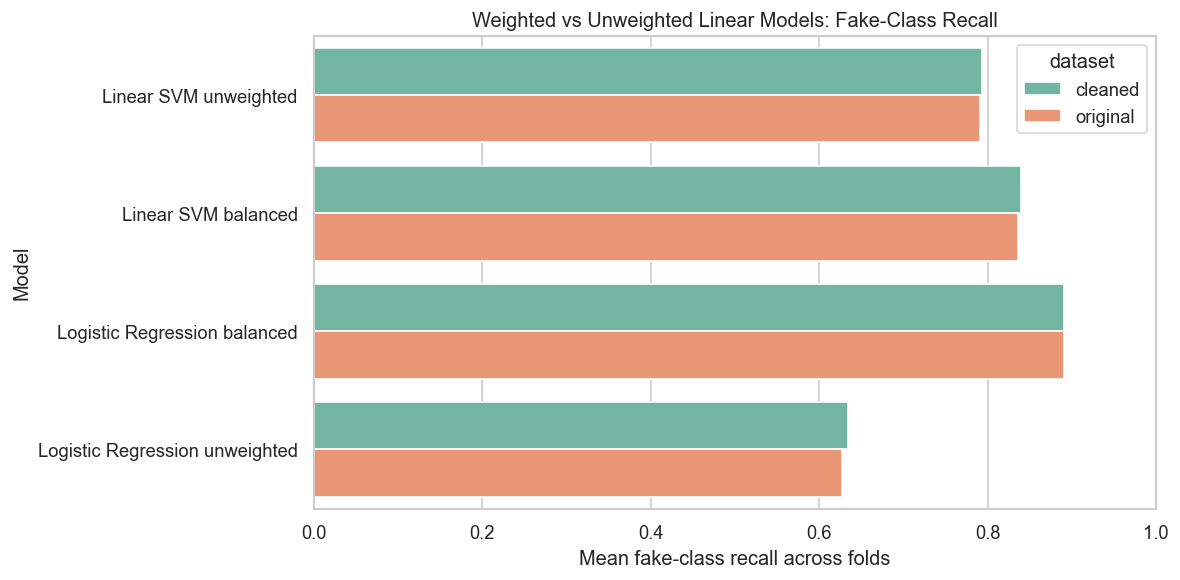

In [11]:
# Compare weighted vs unweighted linear models
weighted_results = []

for dataset_name, df in raw_datasets.items():
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    preprocessor = make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=True)
    weighted_models = {
        'Logistic Regression unweighted': Pipeline([
            ('features', clone(preprocessor)),
            ('model', LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        'Logistic Regression balanced': Pipeline([
            ('features', clone(preprocessor)),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        'Linear SVM unweighted': Pipeline([
            ('features', clone(preprocessor)),
            ('model', LinearSVC(random_state=RANDOM_STATE)),
        ]),
        'Linear SVM balanced': Pipeline([
            ('features', clone(preprocessor)),
            ('model', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
    }

    for model_name, estimator in weighted_models.items():
        print(f'Running {dataset_name} | {model_name}...')
        scores = cross_validate(
            estimator,
            X,
            y,
            cv=cv,
            scoring=SCORING,
            n_jobs=-1,
            return_train_score=False,
            error_score='raise',
        )
        row = {'dataset': dataset_name, 'model': model_name}
        for metric_name in SCORING:
            values = scores[f'test_{metric_name}']
            row[f'{metric_name}_mean'] = values.mean()
            row[f'{metric_name}_std'] = values.std()
        weighted_results.append(row)

weighted_results_df = pd.DataFrame(weighted_results).sort_values(['dataset', 'average_precision_mean'], ascending=[True, False])
display_and_save_table(weighted_results_df.round(4), 'weighted_vs_unweighted_linear_models', index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=weighted_results_df, x='f1_fake_mean', y='model', hue='dataset')
plt.title('Weighted vs Unweighted Linear Models: Fake-Class F1')
plt.xlabel('Mean fake-class F1 across folds')
plt.ylabel('Model')
plt.xlim(0, 1)
savefig('weighted_vs_unweighted_fake_f1')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=weighted_results_df, x='recall_fake_mean', y='model', hue='dataset')
plt.title('Weighted vs Unweighted Linear Models: Fake-Class Recall')
plt.xlabel('Mean fake-class recall across folds')
plt.ylabel('Model')
plt.xlim(0, 1)
savefig('weighted_vs_unweighted_fake_recall')
plt.show()

## Precision-Recall Curves

For imbalanced classification problems, precision-recall curves are often more informative than accuracy. The curve shows the tradeoff between catching more fake jobs and avoiding false alarms among real postings.

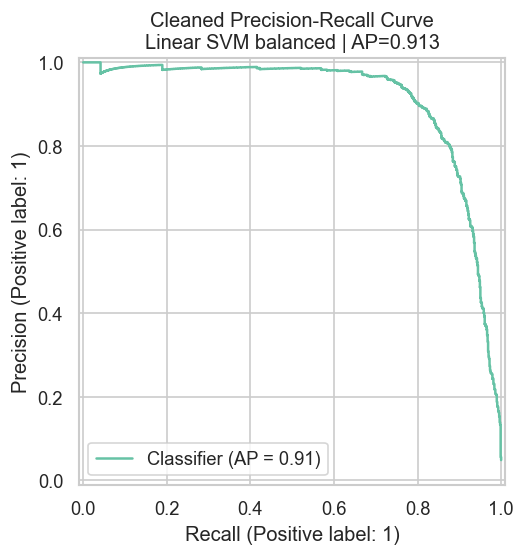

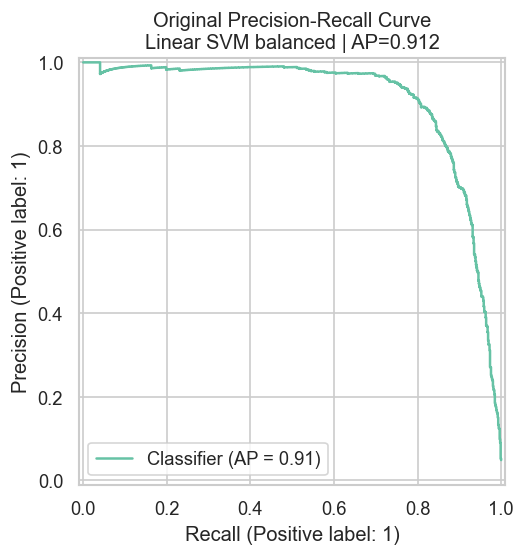

In [12]:
# Precision-recall curves for the best model on each dataset
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

for _, best in best_rows.iterrows():
    dataset_name = best['dataset']
    model_name = best['model']
    df = raw_datasets[dataset_name]
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    estimator = make_models(categorical_cols, numeric_cols)[model_name]

    if hasattr(estimator[-1], 'decision_function'):
        y_score = cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method='decision_function')
    else:
        y_score = cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]

    ap = average_precision_score(y, y_score)
    PrecisionRecallDisplay.from_predictions(y, y_score, pos_label=1)
    plt.title(f'{dataset_name.title()} Precision-Recall Curve\n{model_name} | AP={ap:.3f}')
    savefig(f'{dataset_name}_best_model_precision_recall_curve')
    plt.show()

## Feature Interpretation

Linear models are useful for this project because they allow basic feature interpretation. Positive coefficients push a posting toward the fake class, while negative coefficients push it toward the real class. These features should not be treated as universal proof of fraud, but they help explain what the model learned from this dataset.

### Features Most Associated With Fake Postings

,feature,coefficient
3083,text: link,2.0230
9758,category: department_Information Technology,1.5334
8826,"category: location_US, TX, AUSTIN",1.5306
8621,"category: location_US, OH, Groveport",1.4451
3430,text: money,1.4260
10179,category: department_Sales and Research,1.3807
298,text: american,1.3081
1678,text: duration,1.2949
1695,text: earn,1.2023
9258,category: department_Biotech,1.1549


Saved: results\tables\top_features_associated_with_fake.csv


### Features Most Associated With Real Postings

,feature,coefficient
898,text: client,-1.1843
2003,text: experience,-1.1665
555,text: basic computer,-1.1084
1837,text: english,-1.0241
2405,text: growing,-0.9402
1012,text: companies,-0.9377
2283,text: fun,-0.9375
2000,text: expected,-0.9135
76,text: 50,-0.9019
10582,category: industry_Restaurants,-0.8988


Saved: results\tables\top_features_associated_with_real.csv


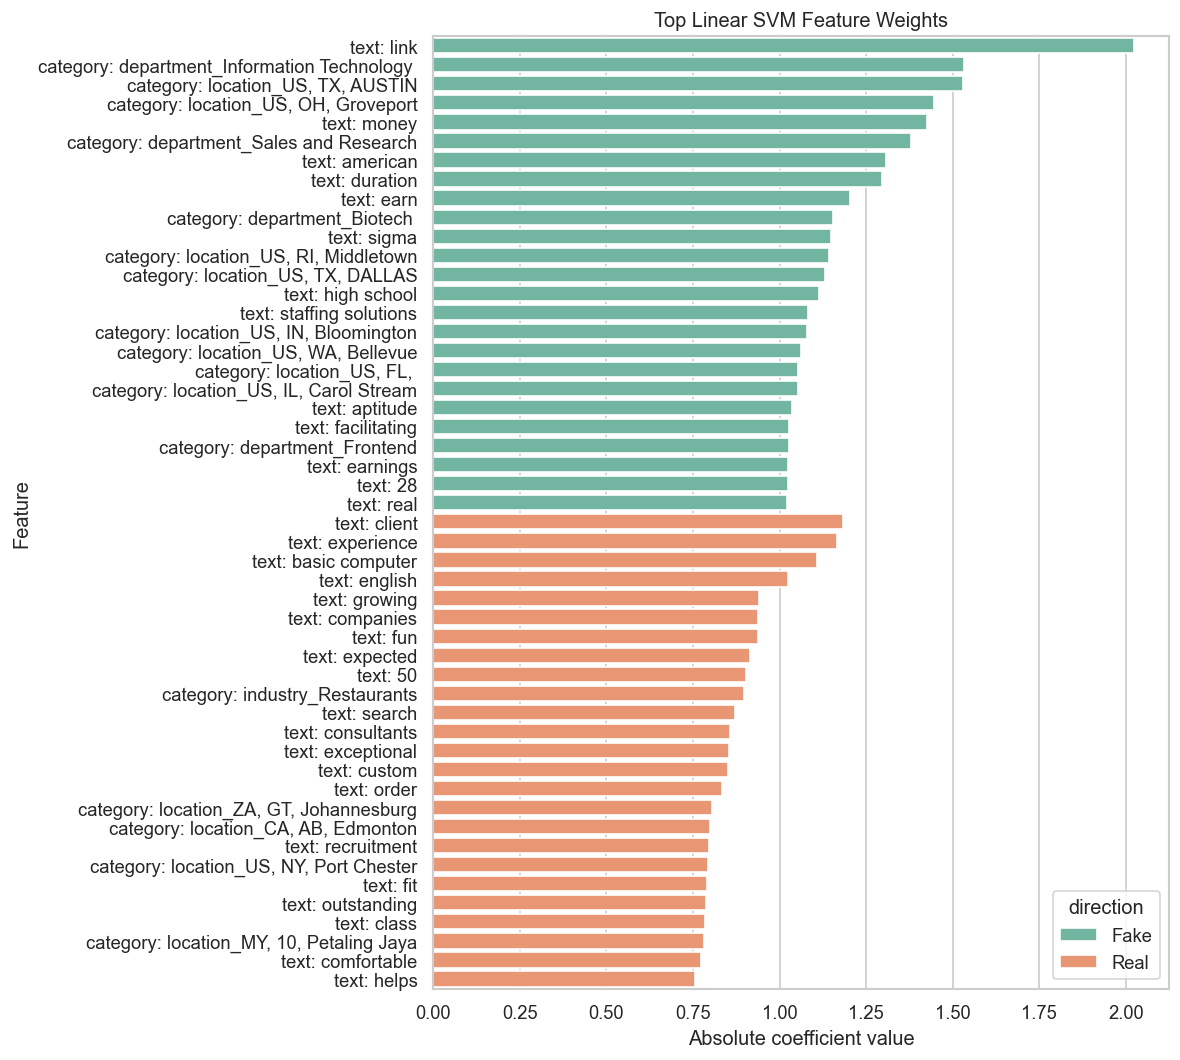

In [13]:
# Interpret top features from the best cleaned linear model
interpret_dataset = 'cleaned'
interpret_model_name = 'Linear SVM balanced'

df = raw_datasets[interpret_dataset]
X, y, categorical_cols, numeric_cols = prepare_features(df)
interpret_model = make_models(categorical_cols, numeric_cols)[interpret_model_name]
interpret_model.fit(X, y)

feature_names = interpret_model.named_steps['features'].get_feature_names_out()
coefs = interpret_model.named_steps['model'].coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['feature'] = coef_df['feature'].str.replace('text__', 'text: ', regex=False)
coef_df['feature'] = coef_df['feature'].str.replace('categorical__', 'category: ', regex=False)
coef_df['feature'] = coef_df['feature'].str.replace('numeric__', 'numeric: ', regex=False)

top_fake_features = coef_df.sort_values('coefficient', ascending=False).head(25)
top_real_features = coef_df.sort_values('coefficient', ascending=True).head(25)

display(Markdown('### Features Most Associated With Fake Postings'))
display_and_save_table(top_fake_features.round(4), 'top_features_associated_with_fake', index=False)

display(Markdown('### Features Most Associated With Real Postings'))
display_and_save_table(top_real_features.round(4), 'top_features_associated_with_real', index=False)

plot_features = pd.concat([
    top_fake_features.assign(direction='Fake'),
    top_real_features.assign(direction='Real')
], ignore_index=True)
plot_features['abs_coefficient'] = plot_features['coefficient'].abs()
plot_features['short_feature'] = plot_features['feature'].str.slice(0, 55)

plt.figure(figsize=(10, 9))
sns.barplot(data=plot_features, x='abs_coefficient', y='short_feature', hue='direction')
plt.title('Top Linear SVM Feature Weights')
plt.xlabel('Absolute coefficient value')
plt.ylabel('Feature')
savefig('top_linear_svm_feature_weights')
plt.show()

## Error Analysis

The final step is to inspect examples the model gets wrong. False positives are real jobs incorrectly flagged as fake. False negatives are fake jobs that the model misses. This is where the project can connect model metrics to practical consequences.

In [14]:
# Error analysis for the best cleaned model
analysis_dataset = 'cleaned'
analysis_model_name = 'Linear SVM balanced'

df = raw_datasets[analysis_dataset].copy()
X, y, categorical_cols, numeric_cols = prepare_features(df)
analysis_model = make_models(categorical_cols, numeric_cols)[analysis_model_name]

y_pred = cross_val_predict(analysis_model, X, y, cv=cv, n_jobs=-1, method='predict')
y_score = cross_val_predict(analysis_model, X, y, cv=cv, n_jobs=-1, method='decision_function')

error_df = df.copy()
error_df['actual_label'] = y.map({0: 'Real', 1: 'Fake'})
error_df['predicted_label'] = pd.Series(y_pred).map({0: 'Real', 1: 'Fake'})
error_df['model_score_for_fake'] = y_score

for col in ['title', 'location', 'employment_type', 'required_experience', 'industry', 'function', 'description']:
    if col not in error_df.columns:
        error_df[col] = ''
error_df['description_snippet'] = error_df['description'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.slice(0, 240)

cols_to_show = [
    'job_id', 'title', 'location', 'employment_type', 'required_experience',
    'industry', 'function', 'actual_label', 'predicted_label',
    'model_score_for_fake', 'description_snippet'
]

false_positives = error_df[(y == 0) & (y_pred == 1)].sort_values('model_score_for_fake', ascending=False)[cols_to_show].head(10)
false_negatives = error_df[(y == 1) & (y_pred == 0)].sort_values('model_score_for_fake', ascending=True)[cols_to_show].head(10)

error_summary = pd.DataFrame({
    'error_type': ['False positives', 'False negatives'],
    'count': [int(((y == 0) & (y_pred == 1)).sum()), int(((y == 1) & (y_pred == 0)).sum())],
})
display_and_save_table(error_summary, 'cleaned_best_model_error_summary', index=False)

display(Markdown('### Highest-Scoring False Positives'))
display_and_save_table(false_positives, 'cleaned_best_model_false_positives', index=False)

display(Markdown('### Lowest-Scoring False Negatives'))
display_and_save_table(false_negatives, 'cleaned_best_model_false_negatives', index=False)

,error_type,count
0,False positives,115
1,False negatives,139


Saved: results\tables\cleaned_best_model_error_summary.csv


### Highest-Scoring False Positives

,job_id,title,location,employment_type,required_experience,industry,function,actual_label,predicted_label,model_score_for_fake,description_snippet
1767,1768,Accounting/Data entry,"US, NY, newyork",Other,Unknown,Accounting,Customer Service,Real,Fake,1.808512,Responsibilities :• Responsible for the delive...
6294,6295,Data Entry,"US, ,",Contract,Unknown,Unknown,Administrative,Real,Fake,1.223769,"This is a data entry position, Working hours a..."
14971,14972,Receptionist - Wellness Practice,"US, KS, Shawnee",Full-time,Unknown,"Health, Wellness and Fitness",Unknown,Real,Fake,1.218888,Hiring: Front office receptionist with a posit...
4003,4004,Customer Service,"US, ,",Other,Unknown,Hospital & Health Care,Customer Service,Real,Fake,1.041984,Our client is seeking an Customer Service with...
5852,5853,Tankage,"MY, 10, Petaling Jaya",Full-time,Mid-Senior level,Oil & Energy,Engineering,Real,Fake,0.954559,A company in oil &amp; gas that has grown into...
16970,16971,Customer Service - Work From Home,"US, GA,",Contract,Entry level,Consumer Services,Customer Service,Real,Fake,0.950776,Do you have 1+ year of customer service/call c...
7744,7745,Customer Service Representative,"CA, ON, Toronto",Full-time,Entry level,Management Consulting,Customer Service,Real,Fake,0.835046,The Customer Service Representative will provi...
8193,8194,Accounting Clerk $15/hr,"US, TX, San Antonio",Full-time,Entry level,Accounting,Accounting/Auditing,Real,Fake,0.746723,The Accounting Clerk will work in a team envir...
15134,15135,Payroll Processor,"US, NY, New York",Contract,Entry level,Accounting,Accounting/Auditing,Real,Fake,0.745254,JOB DESCRIPTIONClassification: Payroll Process...
3317,3318,USE CASE MANAGER FOR BI / BIG DATA PROJECTS IN...,NaN,Full-time,Entry level,Automotive,Unknown,Real,Fake,0.722704,The German Entrepreneurship GmbH is looking fo...


Saved: results\tables\cleaned_best_model_false_positives.csv


### Lowest-Scoring False Negatives

,job_id,title,location,employment_type,required_experience,industry,function,actual_label,predicted_label,model_score_for_fake,description_snippet
17667,17668,Quant Analyst,"GB, LND, London",Full-time,Associate,Banking,Engineering,Fake,Real,-2.406688,Our client is an award winning High-Frequency ...
6363,6364,Integration Engineer with HL7 & EMR.,"US, TX, Plano",Contract,Director,Information Technology and Services,Information Technology,Fake,Real,-1.473813,"Location: Plano, TXDuration: 10 Months Role D..."
9138,9139,Front-End/JavaScript Engineer,"ID, JW, Jakarta",Unknown,Unknown,Unknown,Unknown,Fake,Real,-1.443316,Workable is a product-driven software company....
3711,3712,software development life cycle,"US, GA, Atlanta",Contract,Mid-Senior level,Information Technology and Services,Information Technology,Fake,Real,-1.382896,Title: Service Desk ResourceLocation: Atlanta...
6574,6575,Home Based Commission Roles,"US, IN,",Other,Unknown,Marketing and Advertising,Other,Fake,Real,-1.345515,A Variety of Commission based jobs available.V...
17823,17824,Sales Person Required,"GB, LIN, Immingham",Other,Not Applicable,Staffing and Recruiting,Advertising,Fake,Real,-1.332998,Could this be the most rewarding opportunity a...
1420,1421,Informatica/ Etl Tester,"US, VA, Herndon",Contract,Mid-Senior level,Information Technology and Services,Information Technology,Fake,Real,-1.296651,Position: Informatica Tester Location: Herndon...
3644,3645,Customer Service Representative,"US, FL, Tamarac",Full-time,Entry level,Computer Software,Customer Service,Fake,Real,-1.293547,We are a leading outsourced contact solutions ...
2009,2010,Java Developer,"US, CA, California",Full-time,Internship,Accounting,Customer Service,Fake,Real,-1.254381,Director of Quality AssuranceNomis is searchin...
4811,4812,Sir Awesome,"EE, 37, Tallinn",Part-time,Mid-Senior level,Broadcast Media,Education,Fake,Real,-1.207741,"Lorem ipsum dolor sit amet, consectetur adipis..."


Saved: results\tables\cleaned_best_model_false_negatives.csv


## Expanded Error Analysis: Where the Model Fails

The earlier confusion matrix tells us how many mistakes the model made. This section goes further and asks what kinds of postings are involved in those mistakes.

The analysis focuses on four prediction groups:

- **True positives:** fake postings correctly flagged as fake.
- **False negatives:** fake postings missed by the model.
- **False positives:** real postings incorrectly flagged as fake.
- **True negatives:** real postings correctly ignored.

This helps answer the practical question behind the project: is the model making understandable mistakes, and what tradeoff exists between catching more scams and falsely flagging legitimate jobs?

,count,model_score_for_fake,title_chars_for_analysis,description_chars_for_analysis,requirements_chars_for_analysis,company_profile_chars_for_analysis,benefits_chars_for_analysis,has_company_logo,has_questions,has_salary_range,has_benefits,has_company_profile,has_department
prediction_group,,,,,,,,,,,,,
True positive,727,0.938,31.171,1154.351,441.301,245.927,219.926,0.338,0.275,0.248,0.589,0.331,0.398
False negative,139,-0.545,28.029,1157.367,470.885,152.252,171.770,0.266,0.360,0.309,0.532,0.273,0.331
False positive,115,0.289,26.722,981.330,404.330,121.391,109.696,0.183,0.322,0.330,0.487,0.165,0.348
True negative,16899,-1.746,28.433,1222.852,598.780,644.287,209.402,0.823,0.503,0.154,0.598,0.845,0.353


Saved: results\tables\cleaned_error_group_feature_summary.csv


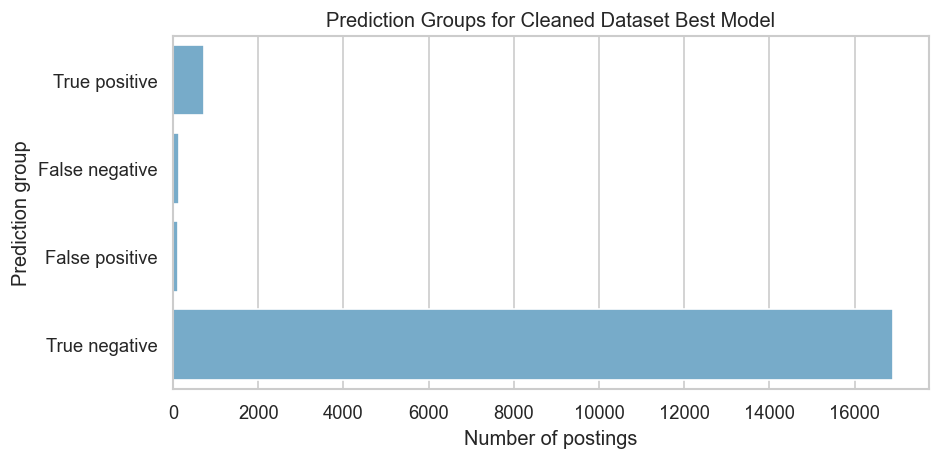

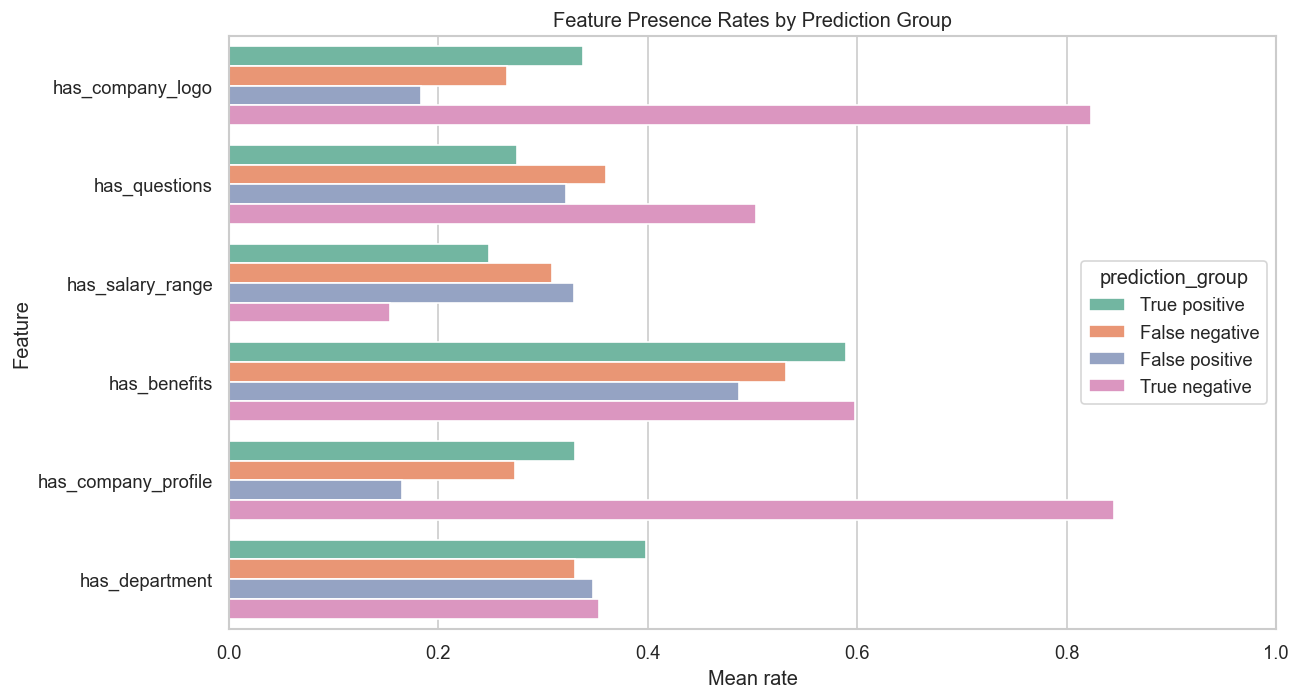

In [15]:
# Expanded error analysis: four prediction groups and feature patterns
analysis_dataset = 'cleaned'
analysis_model_name = 'Linear SVM balanced'

df = raw_datasets[analysis_dataset].copy()
X, y, categorical_cols, numeric_cols = prepare_features(df)
analysis_model = make_models(categorical_cols, numeric_cols)[analysis_model_name]

y_pred = cross_val_predict(analysis_model, X, y, cv=cv, n_jobs=-1, method='predict')
y_score = cross_val_predict(analysis_model, X, y, cv=cv, n_jobs=-1, method='decision_function')

error_df = df.copy()
error_df['actual'] = y.values
error_df['predicted'] = y_pred
error_df['actual_label'] = error_df['actual'].map({0: 'Real', 1: 'Fake'})
error_df['predicted_label'] = error_df['predicted'].map({0: 'Real', 1: 'Fake'})
error_df['model_score_for_fake'] = y_score

conditions = [
    (error_df['actual'].eq(1) & error_df['predicted'].eq(1)),
    (error_df['actual'].eq(1) & error_df['predicted'].eq(0)),
    (error_df['actual'].eq(0) & error_df['predicted'].eq(1)),
    (error_df['actual'].eq(0) & error_df['predicted'].eq(0)),
]
choices = ['True positive', 'False negative', 'False positive', 'True negative']
error_df['prediction_group'] = np.select(conditions, choices, default='Other')

group_order = ['True positive', 'False negative', 'False positive', 'True negative']
error_df['prediction_group'] = pd.Categorical(error_df['prediction_group'], categories=group_order, ordered=True)

# Ensure common analysis columns exist, even if a dataset version lacks one.
for col in ['title', 'description', 'requirements', 'company_profile', 'benefits']:
    if col not in error_df.columns:
        error_df[col] = ''
    error_df[f'{col}_chars_for_analysis'] = error_df[col].fillna('').astype(str).str.len()

for col in ['has_company_logo', 'has_questions', 'has_salary_range', 'has_benefits', 'has_company_profile', 'has_department']:
    if col not in error_df.columns:
        if col == 'has_salary_range' and 'salary_range' in error_df.columns:
            error_df[col] = error_df['salary_range'].notna().astype(int)
        elif col == 'has_benefits' and 'benefits' in error_df.columns:
            error_df[col] = error_df['benefits'].notna().astype(int)
        elif col == 'has_company_profile' and 'company_profile' in error_df.columns:
            error_df[col] = error_df['company_profile'].notna().astype(int)
        elif col == 'has_department' and 'department' in error_df.columns:
            error_df[col] = error_df['department'].notna().astype(int)
        else:
            error_df[col] = np.nan

summary_cols = [
    'model_score_for_fake',
    'title_chars_for_analysis',
    'description_chars_for_analysis',
    'requirements_chars_for_analysis',
    'company_profile_chars_for_analysis',
    'benefits_chars_for_analysis',
    'has_company_logo',
    'has_questions',
    'has_salary_range',
    'has_benefits',
    'has_company_profile',
    'has_department',
]

error_group_summary = error_df.groupby('prediction_group', observed=False)[summary_cols].mean().round(3)
error_group_summary.insert(0, 'count', error_df['prediction_group'].value_counts().reindex(group_order).fillna(0).astype(int))

display_and_save_table(error_group_summary, 'cleaned_error_group_feature_summary')

plt.figure(figsize=(8, 4))
sns.countplot(data=error_df, y='prediction_group', order=group_order, color='#6aaed6')
plt.title('Prediction Groups for Cleaned Dataset Best Model')
plt.xlabel('Number of postings')
plt.ylabel('Prediction group')
savefig('cleaned_error_group_counts')
plt.show()

rate_cols = ['has_company_logo', 'has_questions', 'has_salary_range', 'has_benefits', 'has_company_profile', 'has_department']
rate_plot = error_group_summary[rate_cols].reset_index().melt(id_vars='prediction_group', var_name='feature', value_name='rate')
plt.figure(figsize=(11, 6))
sns.barplot(data=rate_plot, x='rate', y='feature', hue='prediction_group')
plt.title('Feature Presence Rates by Prediction Group')
plt.xlabel('Mean rate')
plt.ylabel('Feature')
plt.xlim(0, 1)
savefig('cleaned_error_group_feature_rates')
plt.show()

### Error Groups by Category

The next table looks at common categorical fields within each prediction group. This helps identify whether certain industries, job functions, employment types, or experience levels are more common among mistakes.

In [16]:
# Top categorical values within each prediction group
category_columns_for_errors = ['industry', 'function', 'employment_type', 'required_experience', 'required_education']
category_rows = []

for group in group_order:
    group_df = error_df[error_df['prediction_group'].eq(group)]
    for col in category_columns_for_errors:
        if col in group_df.columns:
            counts = group_df[col].fillna('missing').astype(str).value_counts().head(5)
            for value, count in counts.items():
                category_rows.append({
                    'prediction_group': group,
                    'column': col,
                    'value': value,
                    'count': int(count),
                    'group_rate': round(count / len(group_df), 4) if len(group_df) else 0,
                })

error_group_top_categories = pd.DataFrame(category_rows)
display_and_save_table(error_group_top_categories, 'cleaned_error_group_top_categories', index=False)

# Compact display for the most project-relevant mistake groups.
for group in ['False positive', 'False negative']:
    display(Markdown(f'#### Top categories: {group}'))
    display(error_group_top_categories[error_group_top_categories['prediction_group'].eq(group)].head(15))

,prediction_group,column,value,count,group_rate
0,True positive,industry,Unknown,227,0.3122
1,True positive,industry,Oil & Energy,109,0.1499
2,True positive,industry,Accounting,53,0.0729
3,True positive,industry,Hospital & Health Care,46,0.0633
4,True positive,industry,Marketing and Advertising,39,0.0536
...,...,...,...,...,...
95,True negative,required_education,Unknown,7598,0.4496
96,True negative,required_education,Bachelor's Degree,5037,0.2981
97,True negative,required_education,High School or equivalent,1881,0.1113
98,True negative,required_education,Unspecified,1329,0.0786


Saved: results\tables\cleaned_error_group_top_categories.csv


#### Top categories: False positive

,prediction_group,column,value,count,group_rate
50,False positive,industry,Unknown,35,0.3043
51,False positive,industry,Accounting,9,0.0783
52,False positive,industry,Hospital & Health Care,9,0.0783
53,False positive,industry,Information Technology and Services,7,0.0609
54,False positive,industry,Oil & Energy,6,0.0522
55,False positive,function,Unknown,52,0.4522
56,False positive,function,Administrative,13,0.1130
57,False positive,function,Customer Service,9,0.0783
58,False positive,function,Sales,9,0.0783
59,False positive,function,Accounting/Auditing,7,0.0609


#### Top categories: False negative

,prediction_group,column,value,count,group_rate
25,False negative,industry,Unknown,48,0.3453
26,False negative,industry,Information Technology and Services,15,0.1079
27,False negative,industry,Marketing and Advertising,6,0.0432
28,False negative,industry,Consumer Services,5,0.0360
29,False negative,industry,Hospitality,5,0.0360
30,False negative,function,Unknown,61,0.4388
31,False negative,function,Customer Service,15,0.1079
32,False negative,function,Information Technology,13,0.0935
33,False negative,function,Administrative,7,0.0504
34,False negative,function,Accounting/Auditing,7,0.0504


## Example-Based Error Discussion

Tables are helpful, but individual examples make the error analysis easier to explain in a presentation or report. The examples below show the most confident false positives and false negatives, along with a short model-facing interpretation.

- **False positives:** real jobs that looked suspicious to the model.
- **False negatives:** fake jobs that looked legitimate enough to escape the model.

In [17]:
# Example-based discussion of false positives and false negatives
for col in ['job_id', 'title', 'location', 'employment_type', 'required_experience', 'industry', 'function', 'description']:
    if col not in error_df.columns:
        error_df[col] = ''

error_df['description_snippet'] = (
    error_df['description']
    .fillna('')
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.slice(0, 260)
)

def explain_error(row):
    reasons = []
    desc = str(row.get('description', '')).lower()
    title = str(row.get('title', '')).lower()
    combined = f'{title} {desc}'
    if any(word in combined for word in ['money', 'earn', 'link', 'click', 'home', 'remote']):
        reasons.append('contains terms that may resemble scam or remote-work language')
    if pd.isna(row.get('company_profile')) or str(row.get('company_profile', '')).strip() == '':
        reasons.append('missing company profile')
    if pd.isna(row.get('requirements')) or str(row.get('requirements', '')).strip() == '':
        reasons.append('missing requirements text')
    if len(str(row.get('description', ''))) < 400:
        reasons.append('short description')
    if row.get('has_company_logo', np.nan) == 0:
        reasons.append('no company logo')
    if not reasons:
        reasons.append('likely reflects subtler text or category patterns learned by the model')
    return '; '.join(reasons[:3])

cols_to_show = [
    'job_id', 'title', 'location', 'employment_type', 'required_experience',
    'industry', 'function', 'actual_label', 'predicted_label',
    'model_score_for_fake', 'description_snippet'
]

false_positive_examples = (
    error_df[error_df['prediction_group'].eq('False positive')]
    .sort_values('model_score_for_fake', ascending=False)
    .head(6)
    .copy()
)
false_negative_examples = (
    error_df[error_df['prediction_group'].eq('False negative')]
    .sort_values('model_score_for_fake', ascending=True)
    .head(6)
    .copy()
)

false_positive_examples['possible_reason_model_was_confused'] = false_positive_examples.apply(explain_error, axis=1)
false_negative_examples['possible_reason_model_was_confused'] = false_negative_examples.apply(explain_error, axis=1)

example_discussion = pd.concat([
    false_positive_examples.assign(error_type='False positive'),
    false_negative_examples.assign(error_type='False negative'),
], ignore_index=True)

example_cols = ['error_type'] + cols_to_show + ['possible_reason_model_was_confused']
example_discussion = example_discussion[example_cols]

display_and_save_table(example_discussion, 'cleaned_error_examples_for_discussion', index=False)

for error_type in ['False positive', 'False negative']:
    display(Markdown(f'### {error_type} examples'))
    display(example_discussion[example_discussion['error_type'].eq(error_type)].head(6))

,error_type,job_id,title,location,employment_type,required_experience,industry,function,actual_label,predicted_label,model_score_for_fake,description_snippet,possible_reason_model_was_confused
0,False positive,1768,Accounting/Data entry,"US, NY, newyork",Other,Unknown,Accounting,Customer Service,Real,Fake,1.808512,Responsibilities :• Responsible for the delive...,contains terms that may resemble scam or remot...
1,False positive,6295,Data Entry,"US, ,",Contract,Unknown,Unknown,Administrative,Real,Fake,1.223769,"This is a data entry position, Working hours a...",contains terms that may resemble scam or remot...
2,False positive,14972,Receptionist - Wellness Practice,"US, KS, Shawnee",Full-time,Unknown,"Health, Wellness and Fitness",Unknown,Real,Fake,1.218888,Hiring: Front office receptionist with a posit...,missing company profile; no company logo
3,False positive,4004,Customer Service,"US, ,",Other,Unknown,Hospital & Health Care,Customer Service,Real,Fake,1.041984,Our client is seeking an Customer Service with...,missing company profile; short description; no...
4,False positive,5853,Tankage,"MY, 10, Petaling Jaya",Full-time,Mid-Senior level,Oil & Energy,Engineering,Real,Fake,0.954559,A company in oil &amp; gas that has grown into...,missing company profile; short description; no...
5,False positive,16971,Customer Service - Work From Home,"US, GA,",Contract,Entry level,Consumer Services,Customer Service,Real,Fake,0.950776,Do you have 1+ year of customer service/call c...,contains terms that may resemble scam or remot...
6,False negative,17668,Quant Analyst,"GB, LND, London",Full-time,Associate,Banking,Engineering,Fake,Real,-2.406688,Our client is an award winning High-Frequency ...,missing company profile; no company logo
7,False negative,6364,Integration Engineer with HL7 & EMR.,"US, TX, Plano",Contract,Director,Information Technology and Services,Information Technology,Fake,Real,-1.473813,"Location: Plano, TXDuration: 10 Months Role D...",contains terms that may resemble scam or remot...
8,False negative,9139,Front-End/JavaScript Engineer,"ID, JW, Jakarta",Unknown,Unknown,Unknown,Unknown,Fake,Real,-1.443316,Workable is a product-driven software company....,contains terms that may resemble scam or remot...
9,False negative,3712,software development life cycle,"US, GA, Atlanta",Contract,Mid-Senior level,Information Technology and Services,Information Technology,Fake,Real,-1.382896,Title: Service Desk ResourceLocation: Atlanta...,missing company profile


Saved: results\tables\cleaned_error_examples_for_discussion.csv


### False positive examples

,error_type,job_id,title,location,employment_type,required_experience,industry,function,actual_label,predicted_label,model_score_for_fake,description_snippet,possible_reason_model_was_confused
0,False positive,1768,Accounting/Data entry,"US, NY, newyork",Other,Unknown,Accounting,Customer Service,Real,Fake,1.808512,Responsibilities :• Responsible for the delive...,contains terms that may resemble scam or remot...
1,False positive,6295,Data Entry,"US, ,",Contract,Unknown,Unknown,Administrative,Real,Fake,1.223769,"This is a data entry position, Working hours a...",contains terms that may resemble scam or remot...
2,False positive,14972,Receptionist - Wellness Practice,"US, KS, Shawnee",Full-time,Unknown,"Health, Wellness and Fitness",Unknown,Real,Fake,1.218888,Hiring: Front office receptionist with a posit...,missing company profile; no company logo
3,False positive,4004,Customer Service,"US, ,",Other,Unknown,Hospital & Health Care,Customer Service,Real,Fake,1.041984,Our client is seeking an Customer Service with...,missing company profile; short description; no...
4,False positive,5853,Tankage,"MY, 10, Petaling Jaya",Full-time,Mid-Senior level,Oil & Energy,Engineering,Real,Fake,0.954559,A company in oil &amp; gas that has grown into...,missing company profile; short description; no...
5,False positive,16971,Customer Service - Work From Home,"US, GA,",Contract,Entry level,Consumer Services,Customer Service,Real,Fake,0.950776,Do you have 1+ year of customer service/call c...,contains terms that may resemble scam or remot...


### False negative examples

,error_type,job_id,title,location,employment_type,required_experience,industry,function,actual_label,predicted_label,model_score_for_fake,description_snippet,possible_reason_model_was_confused
6,False negative,17668,Quant Analyst,"GB, LND, London",Full-time,Associate,Banking,Engineering,Fake,Real,-2.406688,Our client is an award winning High-Frequency ...,missing company profile; no company logo
7,False negative,6364,Integration Engineer with HL7 & EMR.,"US, TX, Plano",Contract,Director,Information Technology and Services,Information Technology,Fake,Real,-1.473813,"Location: Plano, TXDuration: 10 Months Role D...",contains terms that may resemble scam or remot...
8,False negative,9139,Front-End/JavaScript Engineer,"ID, JW, Jakarta",Unknown,Unknown,Unknown,Unknown,Fake,Real,-1.443316,Workable is a product-driven software company....,contains terms that may resemble scam or remot...
9,False negative,3712,software development life cycle,"US, GA, Atlanta",Contract,Mid-Senior level,Information Technology and Services,Information Technology,Fake,Real,-1.382896,Title: Service Desk ResourceLocation: Atlanta...,missing company profile
10,False negative,6575,Home Based Commission Roles,"US, IN,",Other,Unknown,Marketing and Advertising,Other,Fake,Real,-1.345515,A Variety of Commission based jobs available.V...,contains terms that may resemble scam or remot...
11,False negative,17824,Sales Person Required,"GB, LIN, Immingham",Other,Not Applicable,Staffing and Recruiting,Advertising,Fake,Real,-1.332998,Could this be the most rewarding opportunity a...,contains terms that may resemble scam or remot...


## Threshold Analysis

Threshold analysis was performed using the balanced Linear SVM decision scores from cross-validated predictions on the cleaned dataset. Each threshold changes the number of postings predicted as fake.

- Lower thresholds increase fake recall and increase false positives.
- Higher thresholds increase fake precision and increase false negatives.

This analysis shows how model performance changes across different decision thresholds.

,threshold,flagged_count,flagged_rate,true_positives,false_positives,false_negatives,true_negatives,accuracy,balanced_accuracy,fake_precision,fake_recall,fake_f1
0,-0.9649,2682,0.1500,839,1843,27,15171,0.8954,0.9302,0.3128,0.9688,0.4729
1,-0.7289,1788,0.1000,823,965,43,16049,0.9436,0.9468,0.4603,0.9503,0.6202
2,-0.5056,1341,0.0750,807,534,59,16480,0.9668,0.9502,0.6018,0.9319,0.7313
3,-0.0870,894,0.0500,742,152,124,16862,0.9846,0.9239,0.8300,0.8568,0.8432
4,0.0000,842,0.0471,727,115,139,16899,0.9858,0.9164,0.8634,0.8395,0.8513
5,0.2374,716,0.0400,670,46,196,16968,0.9865,0.8855,0.9358,0.7737,0.8470
6,0.6742,537,0.0300,527,10,339,17004,0.9805,0.8040,0.9814,0.6085,0.7512


Saved: results\tables\cleaned_threshold_tradeoff_balanced_linear_svm.csv


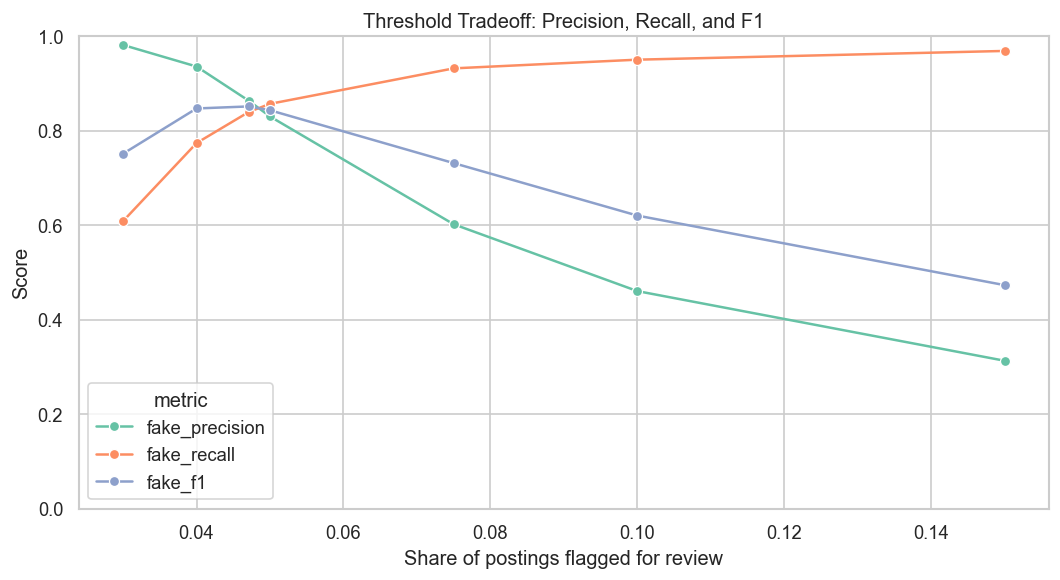

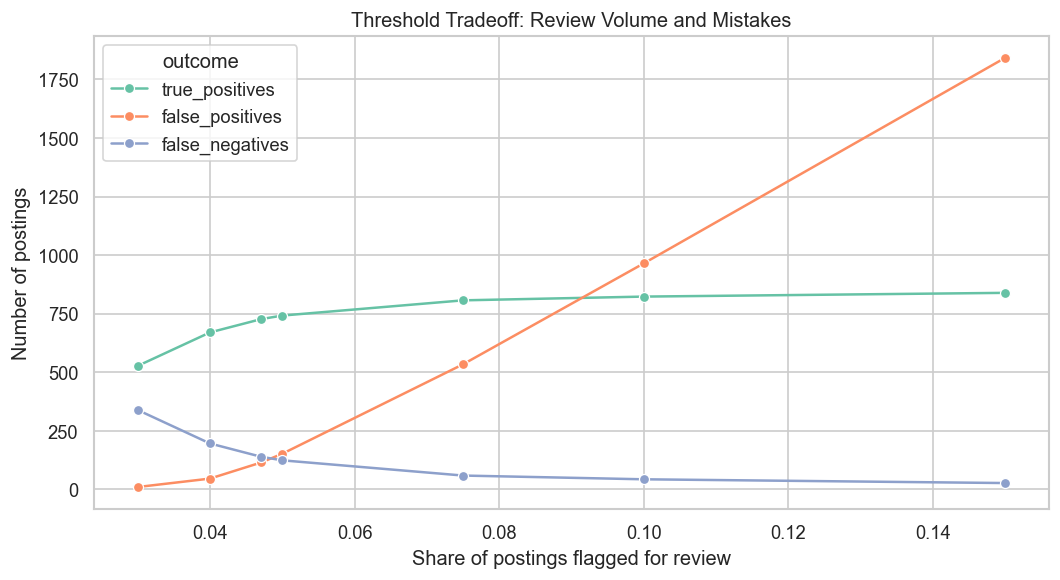

In [18]:
# Threshold tradeoff analysis for the balanced Linear SVM decision scores
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, balanced_accuracy_score

threshold_rows = []
# Use desired flag rates plus the model's default threshold of 0.
flag_rates = [0.03, 0.04, 0.05, 0.075, 0.10, 0.15]
thresholds = sorted({float(np.quantile(y_score, 1 - rate)) for rate in flag_rates} | {0.0})

for threshold in thresholds:
    threshold_pred = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y, threshold_pred, labels=[1], average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, threshold_pred, labels=[0, 1]).ravel()
    threshold_rows.append({
        'threshold': threshold,
        'flagged_count': int(threshold_pred.sum()),
        'flagged_rate': threshold_pred.mean(),
        'true_positives': int(tp),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_negatives': int(tn),
        'accuracy': accuracy_score(y, threshold_pred),
        'balanced_accuracy': balanced_accuracy_score(y, threshold_pred),
        'fake_precision': precision,
        'fake_recall': recall,
        'fake_f1': f1,
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values('threshold').round(4)
display_and_save_table(threshold_df, 'cleaned_threshold_tradeoff_balanced_linear_svm', index=False)

threshold_plot = threshold_df.melt(
    id_vars=['threshold', 'flagged_rate'],
    value_vars=['fake_precision', 'fake_recall', 'fake_f1'],
    var_name='metric',
    value_name='score'
)
plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_plot, x='flagged_rate', y='score', hue='metric', marker='o')
plt.title('Threshold Tradeoff: Precision, Recall, and F1')
plt.xlabel('Share of postings flagged for review')
plt.ylabel('Score')
plt.ylim(0, 1)
savefig('cleaned_threshold_tradeoff_precision_recall_f1')
plt.show()

count_plot = threshold_df.melt(
    id_vars=['threshold', 'flagged_rate'],
    value_vars=['true_positives', 'false_positives', 'false_negatives'],
    var_name='outcome',
    value_name='count'
)
plt.figure(figsize=(9, 5))
sns.lineplot(data=count_plot, x='flagged_rate', y='count', hue='outcome', marker='o')
plt.title('Threshold Tradeoff: Review Volume and Mistakes')
plt.xlabel('Share of postings flagged for review')
plt.ylabel('Number of postings')
savefig('cleaned_threshold_tradeoff_counts')
plt.show()

## Balanced vs Unweighted Linear SVM Tradeoff

The balanced and unweighted Linear SVM models produced different fake-class precision and recall values.

- The balanced Linear SVM had higher fake recall.
- The unweighted Linear SVM had higher fake precision and slightly higher fake F1.

This comparison shows how model selection changes depending on whether the analysis prioritizes recall or precision for the fake class.

In [19]:
# Compact recommendation table for the final report
recommendation_table = weighted_results_df[
    (weighted_results_df['dataset'].eq('cleaned')) &
    (weighted_results_df['model'].isin(['Linear SVM balanced', 'Linear SVM unweighted']))
][[
    'model', 'average_precision_mean', 'precision_fake_mean', 'recall_fake_mean', 'f1_fake_mean', 'balanced_accuracy_mean'
]].copy()

recommendation_table['interpretation'] = recommendation_table['model'].map({
    'Linear SVM balanced': 'Higher fake recall',
    'Linear SVM unweighted': 'Higher fake precision',
})

recommendation_table = recommendation_table.sort_values('recall_fake_mean', ascending=False).round(4)
display_and_save_table(recommendation_table, 'final_model_recommendation_tradeoff', index=False)

,model,average_precision_mean,precision_fake_mean,recall_fake_mean,f1_fake_mean,balanced_accuracy_mean,interpretation
3,Linear SVM balanced,0.9140,0.8636,0.8395,0.8512,0.9164,Higher fake recall
2,Linear SVM unweighted,0.9181,0.9301,0.7933,0.8559,0.8951,Higher fake precision


Saved: results\tables\final_model_recommendation_tradeoff.csv


## Project Conclusion

This project evaluated fake job posting detection as an imbalanced classification problem. Accuracy was not sufficient as the main metric because the fake class represented only about 4.84% of the dataset.

The strongest classic models were Linear SVM models using TF-IDF text features plus available metadata. The cleaned dataset performed only slightly better than the original dataset, suggesting that most predictive signal was already present in the raw text fields.

The expanded error analysis showed how false positives, false negatives, true positives, and true negatives differed across text length, missingness-related features, and categorical fields. Threshold analysis showed that lower thresholds increased fake recall and false positives, while higher thresholds increased fake precision and false negatives.

## Notes for the Final Project

Possible project angle:

Build an interpretable fake job posting detector using classic machine learning, then explain how imbalance changes model evaluation. The cleaned dataset can be framed as the feature-engineered version, while the original dataset is the raw baseline. A good final deliverable would include:

- Class imbalance discussion and why accuracy is misleading.
- EDA findings about missing fields, text length, and high-risk categories.
- Cross-validation table comparing classic models.
- Confusion matrix and classification report for the best model.
- Error analysis of false positives and false negatives.
- A short discussion of ethical limitations: this should support human review, not automatically reject job posts.